# Baseline Fano factor vs mouse age (session level)
Per session, average the baseline-window Fano factor across neurons, and correlate with the mouse's age (days) at that session. Age is computed from Alyx birth date + session start time.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [3]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
ff_path = prefix + 'neural/fano_factor/psths_fanofactor_per_neuron_all_regions_25-06-2026'
clustering_dir = prefix + 'clustering/'

BASELINE = (0.1, 0.3)     # window (s) for the Fano factor
REGION_FILTER = None       # None | 'drop_root' | list of acronyms

lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})

def area_mask(a):
    if REGION_FILTER is None: return np.ones(len(a), dtype=bool)
    if REGION_FILTER == 'drop_root': return (a != 'root').values
    return a.isin(REGION_FILTER).values

print(f"LDA sessions: {lda['session'].nunique()}, mice: {lda['mouse_name'].nunique()}")

LDA sessions: 248, mice: 56


## Session-averaged baseline Fano factor

In [17]:
ff = pd.read_parquet(ff_path)
tcols = sorted([c for c in ff.columns if c.startswith('time_')], key=lambda x: int(x.split('_')[1]))
tsec = np.linspace(-0.5, 1.0, len(tcols))              # FF PSTH spans -0.5..1.0 s
bcols = [c for c, m in zip(tcols, (tsec >= BASELINE[0]) & (tsec <= BASELINE[1])) if m]
print(f"Baseline: {len(bcols)} of {len(tcols)} bins")

ff = ff[area_mask(ff['area'])]
ff['ff_baseline'] = ff[bcols].mean(axis=1)
ff_session = ff.groupby('session', as_index=False)['ff_baseline'].mean()
print(f"Sessions with FF: {len(ff_session)}; mean baseline FF = {ff_session['ff_baseline'].mean():.3f}")

Baseline: 11 of 85 bins
Sessions with FF: 244; mean baseline FF = 1.678


## Mouse age at each session (from Alyx)

In [18]:
# Age per session, cached to disk (Alyx queries are slow -> only fetched once).
AGE_CACHE = prefix + 'neural/fano_factor/session_age.parquet'
FORCE_REFRESH = False   # set True to re-query Alyx

if os.path.exists(AGE_CACHE) and not FORCE_REFRESH:
    age = pd.read_parquet(AGE_CACHE)
    print(f"Loaded cached age from {AGE_CACHE}  ({len(age)} sessions)")
else:
    from one.api import ONE
    one = ONE(mode='remote')

    dob = {}
    for m in lda['mouse_name'].unique():
        try:
            dob[m] = one.alyx.rest('subjects', 'read', id=m).get('birth_date')
        except Exception:
            dob[m] = None

    sdate = {}
    for eid in lda['session'].unique():
        try:
            sdate[eid] = one.alyx.rest('sessions', 'read', id=eid).get('start_time')
        except Exception:
            sdate[eid] = None

    age = lda[['session', 'mouse_name', 'lda_1']].copy()
    age['dob'] = pd.to_datetime(age['mouse_name'].map(dob), errors='coerce')
    age['session_date'] = pd.to_datetime(age['session'].map(sdate), format='ISO8601',
                                         utc=True, errors='coerce').dt.tz_localize(None)
    age['age_days'] = (age['session_date'] - age['dob']).dt.days
    age.to_parquet(AGE_CACHE)
    print(f"Fetched from Alyx and cached to {AGE_CACHE}  ({len(age)} sessions)")

print(f"Sessions with age: {age['age_days'].notna().sum()}")
print(f"Age range (days): {age['age_days'].min():.0f} - {age['age_days'].max():.0f}")

Loaded cached age from /home/ines/repositories/representation_learning_variability/paper-individuality/neural/fano_factor/session_age.parquet  (248 sessions)
Sessions with age: 248
Age range (days): 115 - 432


## Correlation

In [19]:
df = ff_session.merge(age[['session', 'age_days', 'lda_1']], on='session', how='inner').dropna(subset=['ff_baseline', 'age_days'])
r, p = pearsonr(df['age_days'], df['ff_baseline'])
rho, pp = spearmanr(df['age_days'], df['ff_baseline'])
print("="*60)
print("Baseline Fano factor vs mouse age (session level)")
print("="*60)
print(f"n_sessions = {len(df)}")
print(f"pearson  r   = {r:+.3f}  p = {p:.3e}")
print(f"spearman rho = {rho:+.3f}  p = {pp:.3e}")

Baseline Fano factor vs mouse age (session level)
n_sessions = 244
pearson  r   = -0.135  p = 3.486e-02
spearman rho = -0.215  p = 7.115e-04


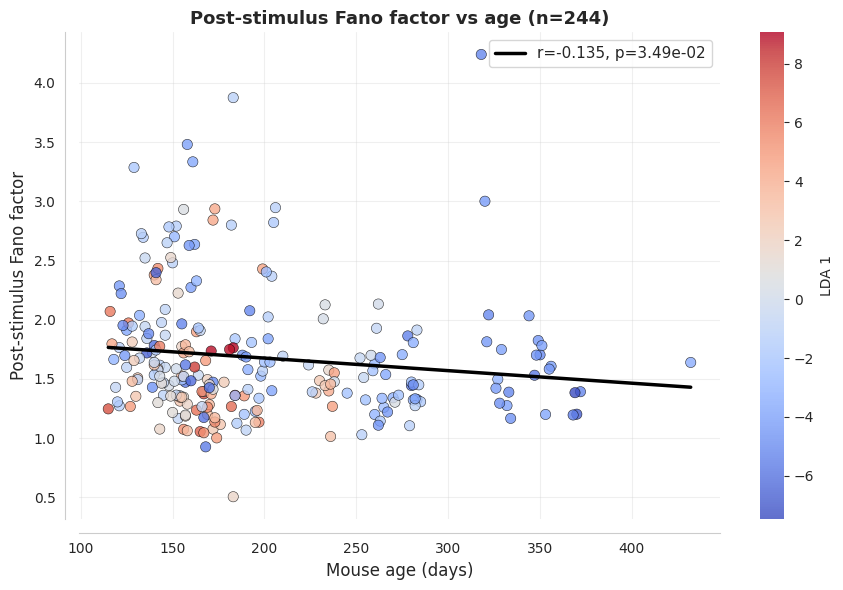

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
x = df['age_days'].values; y = df['ff_baseline'].values
sc = ax.scatter(x, y, c=df['lda_1'].values, cmap='coolwarm', alpha=0.8, s=55, edgecolors='black', linewidth=0.4)
z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={r:.3f}, p={p:.2e}')
cb = fig.colorbar(sc, ax=ax); cb.set_label('LDA 1'); cb.outline.set_visible(False)
ax.set_xlabel('Mouse age (days)', fontsize=12); ax.set_ylabel('Post-stimulus Fano factor', fontsize=12)
ax.set_title(f'Post-stimulus Fano factor vs age (n={len(df)})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); sns.despine(ax=ax, offset=10)
plt.tight_layout(); plt.show()